In [1]:
from google.colab import files
uploaded = files.upload()

json_file = list(uploaded.keys())[0]
print(f"Uploaded file: {json_file}")

Saving GoldCoast_Carlton_VFL_tracking (1).json to GoldCoast_Carlton_VFL_tracking (1).json
Uploaded file: GoldCoast_Carlton_VFL_tracking (1).json


In [2]:
import json
import pandas as pd

with open(json_file, "r") as f:
    data = json.load(f)

rows = []

tracking_results = data.get("tracking_results", [])

for frame in tracking_results:
    frame_number = frame.get("frame_number")
    timestamp = frame.get("timestamp")
    players = frame.get("players", [])

    for player in players:
        bbox = player.get("bbox", {})
        center = player.get("center", {})

        rows.append({
            "frame_number": frame_number,
            "timestamp": timestamp,
            "player_id": player.get("player_id"),
            "center_x": center.get("x"),
            "center_y": center.get("y"),
            "confidence": player.get("confidence"),
            "width": player.get("width"),
            "height": player.get("height"),
            "bbox_x1": bbox.get("x1"),
            "bbox_y1": bbox.get("y1"),
            "bbox_x2": bbox.get("x2"),
            "bbox_y2": bbox.get("y2")
        })

df = pd.DataFrame(rows)

print("Flattened tracking data:")
print(df.head())
print("\nShape:", df.shape)

Flattened tracking data:
   frame_number  timestamp  player_id  center_x  center_y  confidence  width  \
0             1      0.000          1        17       449        0.11     18   
1             2      0.034          1        17       449        0.12     18   
2             3      0.069          1        11       449        0.24     19   
3             5      0.138          1         4       454        0.11      8   
4             8      0.241          1       610       355        0.25     13   

   height  bbox_x1  bbox_y1  bbox_x2  bbox_y2  
0      25        8      437       27      462  
1      25        8      437       27      462  
2      23        1      437       21      461  
3      24        0      441        8      466  
4      16      603      347      617      363  

Shape: (21600, 12)


In [3]:
flattened_csv = "flattened_tracking_data.csv"
df.to_csv(flattened_csv, index=False)

print(f"Saved: {flattened_csv}")

Saved: flattened_tracking_data.csv


In [4]:
import pandas as pd
import numpy as np

CONFIDENCE_THRESHOLD = 0.20
analysis_df = df[df["confidence"] >= CONFIDENCE_THRESHOLD].copy()

analysis_df = analysis_df.sort_values(["player_id", "timestamp"]).reset_index(drop=True)

analysis_df["prev_x"] = analysis_df.groupby("player_id")["center_x"].shift(1)
analysis_df["prev_y"] = analysis_df.groupby("player_id")["center_y"].shift(1)
analysis_df["prev_t"] = analysis_df.groupby("player_id")["timestamp"].shift(1)

analysis_df["dx"] = analysis_df["center_x"] - analysis_df["prev_x"]
analysis_df["dy"] = analysis_df["center_y"] - analysis_df["prev_y"]
analysis_df["dt"] = analysis_df["timestamp"] - analysis_df["prev_t"]

analysis_df.loc[analysis_df["dt"] <= 0, "dt"] = np.nan

analysis_df["step_distance"] = np.sqrt(analysis_df["dx"]**2 + analysis_df["dy"]**2)

analysis_df["speed"] = analysis_df["step_distance"] / analysis_df["dt"]

analysis_df["prev_speed"] = analysis_df.groupby("player_id")["speed"].shift(1)
analysis_df["acceleration"] = (analysis_df["speed"] - analysis_df["prev_speed"]) / analysis_df["dt"]

time_visible_df = (
    analysis_df.groupby("player_id")["timestamp"]
    .agg(["min", "max"])
    .reset_index()
)
time_visible_df["time_visible"] = time_visible_df["max"] - time_visible_df["min"]
time_visible_df = time_visible_df[["player_id", "time_visible"]]

metrics = analysis_df.groupby("player_id").agg(
    total_distance_covered=("step_distance", "sum"),
    average_speed=("speed", "mean"),
    peak_speed=("speed", "max"),
    average_acceleration=("acceleration", "mean")
).reset_index()

metrics = metrics.merge(time_visible_df, on="player_id", how="left")

metrics = metrics.round(2)

print("Tracked ID Performance Metrics")
print(metrics.head(20))

Tracked ID Performance Metrics
    player_id  total_distance_covered  average_speed  peak_speed  \
0           1              1904710.42        2978.45    36594.90   
1           2               223311.81        1572.32    29411.78   
2           3                19948.83         833.45    16055.48   
3           4                 1696.87          25.16      147.90   
4           5                    0.00            NaN         NaN   
5           8                    1.00          28.57       28.57   
6          13                    0.00            NaN         NaN   
7          27                    4.47           3.82        7.63   
8          30                    3.00          85.71       85.71   
9          32                    0.00            NaN         NaN   
10         39                    9.64          93.33      121.22   
11         40                    0.00            NaN         NaN   
12         44                    0.00            NaN         NaN   
13         45    

In [5]:
metrics_csv = "player_metrics_summary.csv"
metrics.to_csv(metrics_csv, index=False)

print(f"Saved: {metrics_csv}")

Saved: player_metrics_summary.csv


In [6]:
detection_counts = (
    analysis_df.groupby("player_id")
    .size()
    .reset_index(name="detection_count")
)

comparison_df = metrics.merge(detection_counts, on="player_id", how="left")

print("Comparison Table")
print(comparison_df.head(20))

Comparison Table
    player_id  total_distance_covered  average_speed  peak_speed  \
0           1              1904710.42        2978.45    36594.90   
1           2               223311.81        1572.32    29411.78   
2           3                19948.83         833.45    16055.48   
3           4                 1696.87          25.16      147.90   
4           5                    0.00            NaN         NaN   
5           8                    1.00          28.57       28.57   
6          13                    0.00            NaN         NaN   
7          27                    4.47           3.82        7.63   
8          30                    3.00          85.71       85.71   
9          32                    0.00            NaN         NaN   
10         39                    9.64          93.33      121.22   
11         40                    0.00            NaN         NaN   
12         44                    0.00            NaN         NaN   
13         45                  

In [7]:
comparison_df.to_csv("player_comparison_metrics.csv", index=False)
print("Saved: player_comparison_metrics.csv")

Saved: player_comparison_metrics.csv


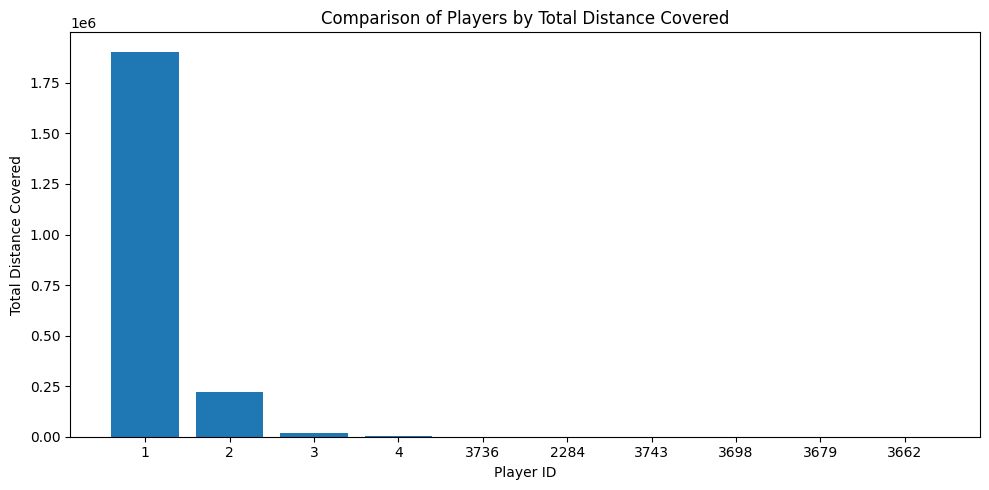

In [8]:
import matplotlib.pyplot as plt

plot_df = comparison_df.sort_values("total_distance_covered", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["player_id"].astype(str), plot_df["total_distance_covered"])
plt.xlabel("Player ID")
plt.ylabel("Total Distance Covered")
plt.title("Comparison of Players by Total Distance Covered")
plt.tight_layout()
plt.show()

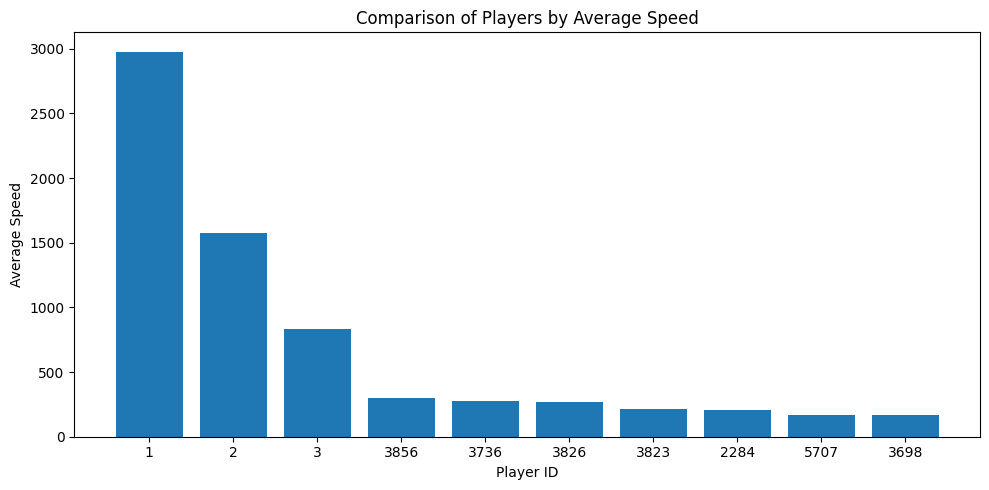

In [9]:
plot_df = comparison_df.sort_values("average_speed", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["player_id"].astype(str), plot_df["average_speed"])
plt.xlabel("Player ID")
plt.ylabel("Average Speed")
plt.title("Comparison of Players by Average Speed")
plt.tight_layout()
plt.show()

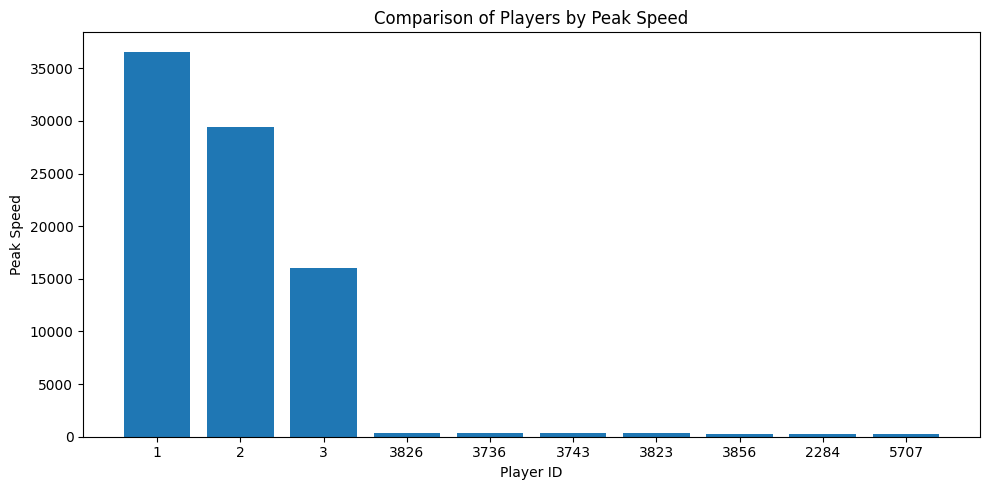

In [10]:
plot_df = comparison_df.sort_values("peak_speed", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["player_id"].astype(str), plot_df["peak_speed"])
plt.xlabel("Player ID")
plt.ylabel("Peak Speed")
plt.title("Comparison of Players by Peak Speed")
plt.tight_layout()
plt.show()

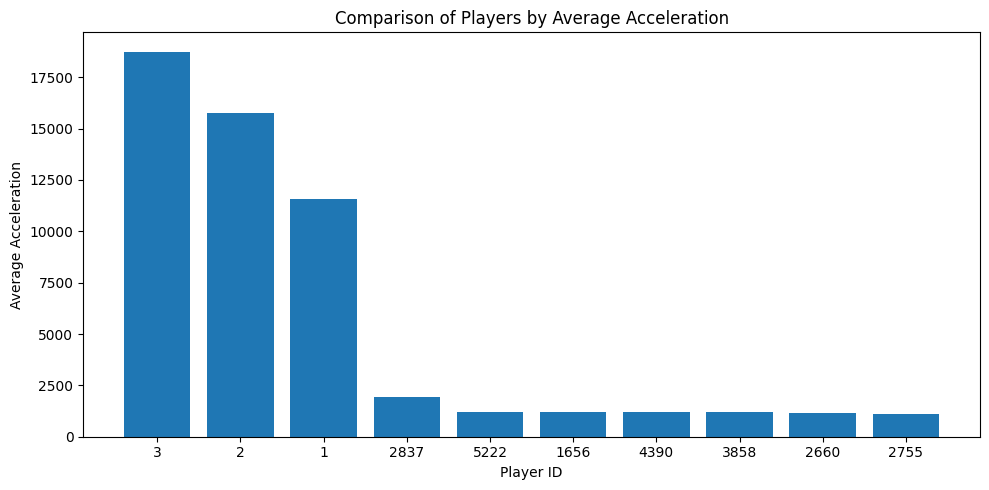

In [11]:
plot_df = comparison_df.sort_values("average_acceleration", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["player_id"].astype(str), plot_df["average_acceleration"])
plt.xlabel("Player ID")
plt.ylabel("Average Acceleration")
plt.title("Comparison of Players by Average Acceleration")
plt.tight_layout()
plt.show()

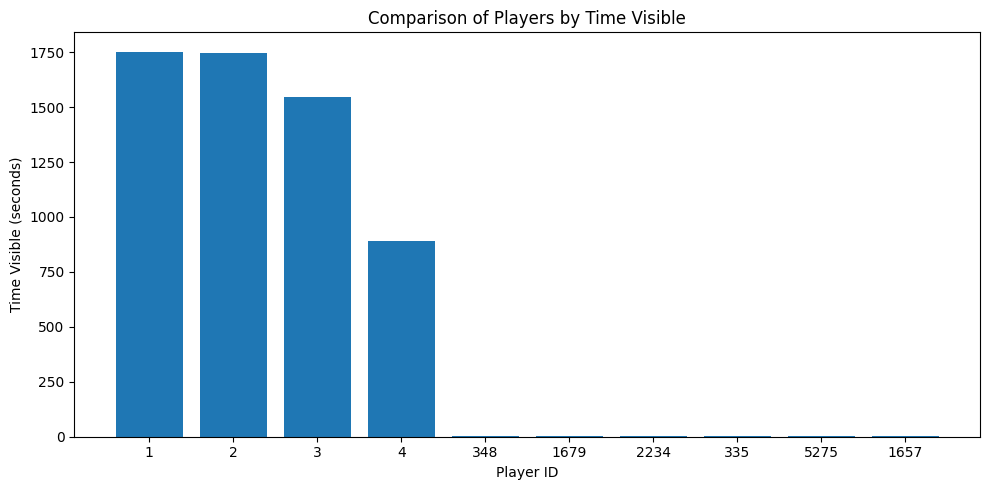

In [12]:
plot_df = comparison_df.sort_values("time_visible", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["player_id"].astype(str), plot_df["time_visible"])
plt.xlabel("Player ID")
plt.ylabel("Time Visible (seconds)")
plt.title("Comparison of Players by Time Visible")
plt.tight_layout()
plt.show()

In [13]:
from google.colab import files
files.download("player_comparison_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>